In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight


In [9]:
# Load dataset from scikit-learn directly
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

# Convert it into a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Top 5 rows of the dataset")
display(df.head())

print("Bottom 5 rows of the dataset")
display(df.tail())

print("Shape of the dataset")
display(df.shape)

print("General info about the dataset")
display(df.info())

Top 5 rows of the dataset


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Bottom 5 rows of the dataset


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


Shape of the dataset


(569, 31)

General info about the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64


None

In [11]:
# Filter and display all rows that are duplicates
duplicates = df[df.duplicated()]
print("Number of duplicate rows:", duplicates.shape[0])
display(duplicates)

Number of duplicate rows: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


In [3]:
# Check for missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [4]:
# Summary statistics of the data
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [12]:
df.skew()

mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150237
worst concave points       0

#### area error	5.44	Extremely skewed — many small values, few very large outliers
#### concavity error	5.11	Same as above — likely needs transformation (e.g. log or sqrt)
#### fractal dimension error	3.92	Highly right-skewed
#### perimeter error	3.44	Outlier-prone
#### radius error	3.08	Strong skew
#### smoothness error	2.31	Moderate skew

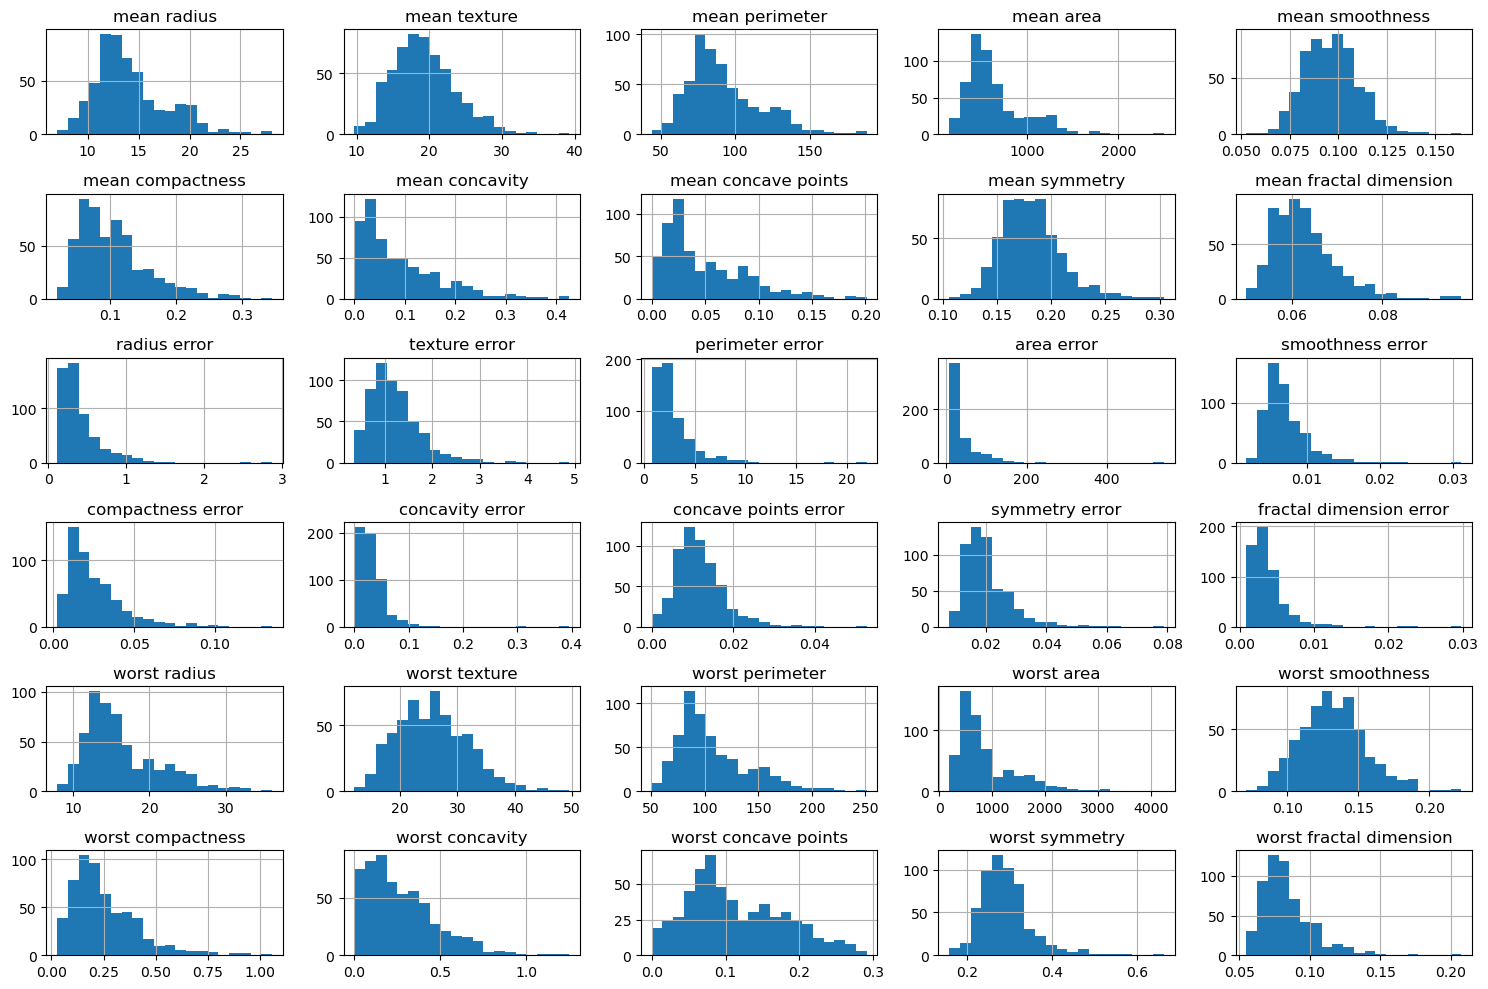

In [12]:
# Plot histograms of the features
df.drop('target', axis=1).hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()


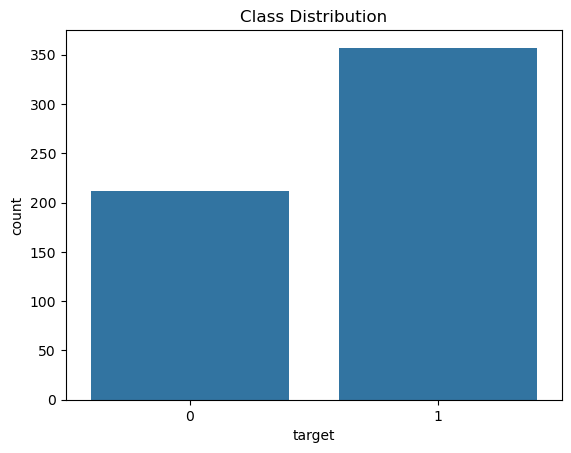

target
1    357
0    212
Name: count, dtype: int64

In [9]:
# Check the distribution of the target (cancer class)
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.show()

# Check the count of each class
df['target'].value_counts()


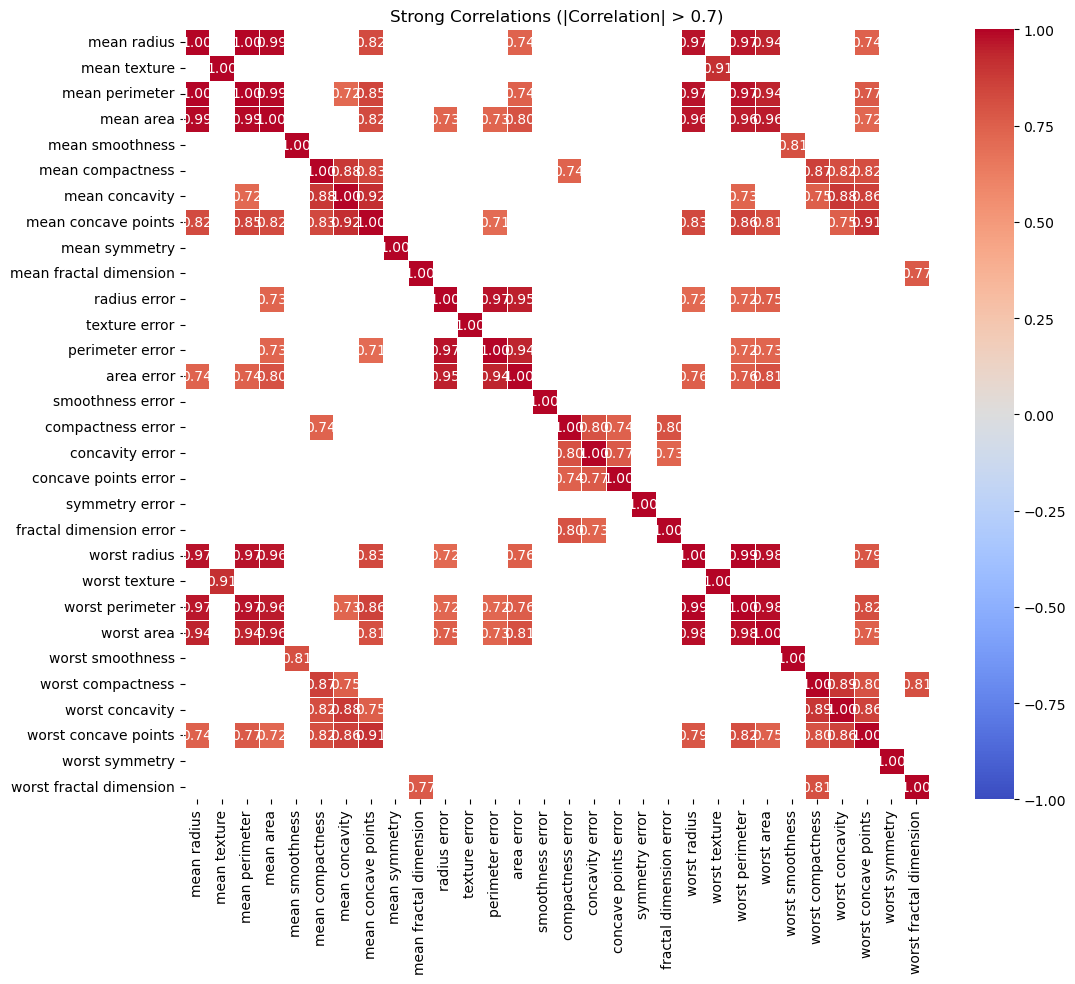

In [16]:
# Calculate the correlation matrix excluding the 'target' column
corr_matrix = df.drop('target', axis=1).corr()

# Filter the correlation matrix to only include correlations greater than 0.7 or less than -0.7
strong_corr = corr_matrix[(corr_matrix > 0.7) | (corr_matrix < -0.7)]

# Set up the figure size for better visibility
plt.figure(figsize=(12, 10))

# Plot the heatmap of the filtered correlations
sns.heatmap(strong_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

# Add a title and show the plot
plt.title('Strong Correlations (|Correlation| > 0.7)')
plt.show()


In [17]:
# Calculate the correlation matrix excluding the 'target' column
corr_matrix = df.drop('target', axis=1).corr()

# Create a mask for correlation > 0.7 or < -0.7
strong_corr_pairs = corr_matrix.unstack()
strong_corr_pairs = strong_corr_pairs[(strong_corr_pairs > 0.7) | (strong_corr_pairs < -0.7)]

# Remove duplicate pairs (e.g., (A, B) and (B, A))
strong_corr_pairs = strong_corr_pairs[strong_corr_pairs.index.get_level_values(0) < strong_corr_pairs.index.get_level_values(1)]

# Convert the series to a DataFrame for better readability
strong_corr_df = strong_corr_pairs.reset_index(name='Correlation')

# Display the table of strong correlations
print(strong_corr_df)


                 level_0                  level_1  Correlation
0            mean radius             worst radius     0.969539
1            mean radius          worst perimeter     0.965137
2            mean radius               worst area     0.941082
3            mean radius     worst concave points     0.744214
4           mean texture            worst texture     0.912045
..                   ...                      ...          ...
65     worst compactness     worst concave points     0.801080
66     worst compactness  worst fractal dimension     0.810455
67  worst concave points             worst radius     0.787424
68  worst concave points          worst perimeter     0.816322
69  worst concave points          worst concavity     0.855434

[70 rows x 3 columns]


Many of the strongest correlations involve mean vs. worst versions of the same feature (e.g., mean radius and worst radius, mean area and worst area).
This indicates feature redundancy, which could lead to multicollinearity in certain models, especially linear models, which don't perform well with highly correlated features.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
# Split the data into features and target
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model (no scaling or feature selection)
model = LogisticRegression(max_iter=10000)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.956140350877193

Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



* True Negatives (TN): 39
* False Positives (FP): 4
* False Negatives (FN): 1
* True Positives (TP): 70
* This matrix shows that the model has:

* A high true positive rate (accurately identifying malignant tumors),
* A very low false negative rate (only 1 malignant tumor was missed),
* A relatively low false positive rate (4 benign tumors wrongly classified as malignant).

* Precision for class 0 (benign): 0.97 — The model correctly identified 97% of benign cases.
* Recall for class 0 (benign): 0.91 — The model correctly identified 91% of all benign cases.
* Precision for class 1 (malignant): 0.95 — The model correctly identified 95% of malignant cases.
* Recall for class 1 (malignant): 0.99 — The model correctly identified 99% of all malignant cases.

* Accuracy: 95.6% is very high. Given that this is a binary classification problem (benign vs malignant), this accuracy suggests a strong model.


* While Logistic Regression is a solid starting point, more complex models like Random Forest, SVM, or XGBoost could potentially improve performance, especially in terms of model robustness or handling interactions between features.

* In a medical setting, false negatives (failing to identify malignant tumors) are much more costly than false positives. We can adjust the decision threshold to reduce false negatives even further, perhaps by tuning the model to favor recall (sensitivity) over precision,